# Automotive Demand Response Analyzer with DuckDB

### DSCI 551 Course Project Demo
##### May Tong
**Focus area:** Columnar storage and vectorized execution in DuckDB

This project analyzes how incentives and pricing relate to vehicle sales across regions and time.  
The main goal is to show how DuckDB's internal design makes analytical queries efficient.

In [ ]:
!pip install duckdb

In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", None)

In [ ]:
con = duckdb.connect()
print("Connected to DuckDB")

Connected to DuckDB


## 1. Generate Synthetic Dataset
This creates a realistic looking automotive sales dataset with regions, segments, prices, incentives, and units sold.

In [ ]:
np.random.seed(42)

n = 300_000

sale_dates = pd.date_range(start="2023-01-01", periods=n, freq="H")

regions = np.random.choice(
    ["West", "East", "South", "Midwest"],
    size=n,
    p=[0.30, 0.25, 0.25, 0.20]
)

segments = np.random.choice(
    ["SUV", "Sedan", "EV", "Truck"],
    size=n,
    p=[0.35, 0.25, 0.20, 0.20]
)

base_msrp_map = {
    "SUV": 42000,
    "Sedan": 28000,
    "EV": 50000,
    "Truck": 46000
}

base_incentive_map = {
    "West": 2500,
    "East": 1800,
    "South": 2200,
    "Midwest": 1500
}

msrp = []
incentive = []
units_sold = []

for i in range(n):
    seg = segments[i]
    reg = regions[i]

    seg_msrp = base_msrp_map[seg] + np.random.randint(-5000, 5001)
    reg_incentive = base_incentive_map[reg] + np.random.randint(-700, 701)

    base_units = {
        "SUV": 3.2,
        "Sedan": 2.7,
        "EV": 2.1,
        "Truck": 2.9
    }[seg]

    regional_adjustment = {
        "West": 0.4,
        "East": 0.2,
        "South": 0.3,
        "Midwest": 0.1
    }[reg]

    incentive_adjustment = reg_incentive / 2500
    estimated_units = base_units + regional_adjustment + 0.35 * incentive_adjustment
    sold = max(1, int(round(np.random.normal(loc=estimated_units, scale=0.8))))

    msrp.append(seg_msrp)
    incentive.append(max(0, reg_incentive))
    units_sold.append(sold)

df = pd.DataFrame({
    "sale_date": sale_dates,
    "region": regions,
    "segment": segments,
    "msrp": msrp,
    "incentive": incentive,
    "units_sold": units_sold
})

df["revenue"] = (df["msrp"] - df["incentive"]) * df["units_sold"]

df.head()

/tmp/ipykernel_538/543388277.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sale_dates = pd.date_range(start="2023-01-01", periods=n, freq="H")


,sale_date,region,segment,msrp,incentive,units_sold,revenue
0,2023-01-01 00:00:00,East,SUV,38257,1433,3,110472
1,2023-01-01 01:00:00,Midwest,SUV,40628,1194,2,78868
2,2023-01-01 02:00:00,South,SUV,38350,2581,4,143076
3,2023-01-01 03:00:00,South,Sedan,25657,2222,5,117175
4,2023-01-01 04:00:00,West,Truck,48414,3070,3,136032


## 2. Create and Load the DuckDB Table
This creates the sales table and loads the generated data into DuckDB.

In [ ]:
con.execute("DROP TABLE IF EXISTS sales")
con.execute("CREATE TABLE sales AS SELECT * FROM df")
print("Table 'sales' created and loaded into DuckDB")

Table 'sales' created and loaded into DuckDB


## 3. Verify Setup
These checks show that the database is working, the schema exists, and the table has data.

In [ ]:
print("Row count:")
display(con.execute("SELECT COUNT(*) AS total_rows FROM sales").fetchdf())

print("Schema:")
display(con.execute("DESCRIBE sales").fetchdf())

print("Sample rows:")
display(con.execute("SELECT * FROM sales LIMIT 5").fetchdf())

Row count:


,total_rows
0,300000


Schema:


,column_name,column_type,null,key,default,extra
0,sale_date,TIMESTAMP_NS,YES,None,None,None
1,region,VARCHAR,YES,None,None,None
2,segment,VARCHAR,YES,None,None,None
3,msrp,BIGINT,YES,None,None,None
4,incentive,BIGINT,YES,None,None,None
5,units_sold,BIGINT,YES,None,None,None
6,revenue,BIGINT,YES,None,None,None


Sample rows:


,sale_date,region,segment,msrp,incentive,units_sold,revenue
0,2023-01-01 00:00:00,East,SUV,38257,1433,3,110472
1,2023-01-01 01:00:00,Midwest,SUV,40628,1194,2,78868
2,2023-01-01 02:00:00,South,SUV,38350,2581,4,143076
3,2023-01-01 03:00:00,South,Sedan,25657,2222,5,117175
4,2023-01-01 04:00:00,West,Truck,48414,3070,3,136032


## 4. Application Feature 1: Regional Demand Analysis
This query calculates total units sold by region.

In [ ]:
query1 = """
SELECT region, SUM(units_sold) AS total_units
FROM sales
GROUP BY region
ORDER BY total_units DESC
"""

result1 = con.execute(query1).fetchdf()
display(result1)

,region,total_units
0,West,318121.0
1,South,256342.0
2,East,243358.0
3,Midwest,186797.0


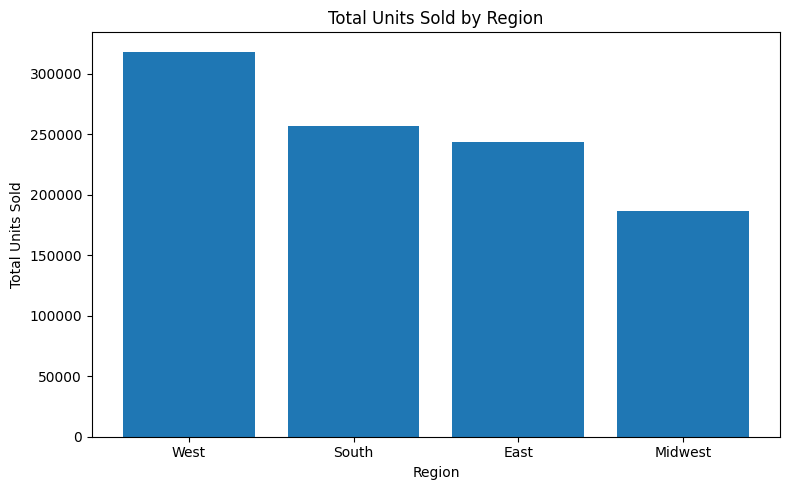

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(result1["region"], result1["total_units"])
plt.title("Total Units Sold by Region")
plt.xlabel("Region")
plt.ylabel("Total Units Sold")
plt.tight_layout()
plt.show()

### Internal Mapping for Feature 1
- **What the application does:** computes total vehicle sales by region  
- **What DuckDB does internally:** scans only the `region` and `units_sold` columns  
- **Why it matters:** columnar storage avoids reading unnecessary data, and vectorized execution makes aggregation faster

## 5. Application Feature 2: Monthly Sales Trends
This query analyzes sales over time by month.

In [ ]:
query2 = """
SELECT DATE_TRUNC('month', sale_date) AS month,
       SUM(units_sold) AS total_units
FROM sales
GROUP BY month
ORDER BY month
"""

result2 = con.execute(query2).fetchdf()
display(result2.head(12))

,month,total_units
0,2023-01-01,2512.0
1,2023-02-01,2291.0
2,2023-03-01,2496.0
3,2023-04-01,2378.0
4,2023-05-01,2505.0
5,2023-06-01,2390.0
6,2023-07-01,2501.0
7,2023-08-01,2527.0
8,2023-09-01,2453.0
9,2023-10-01,2487.0


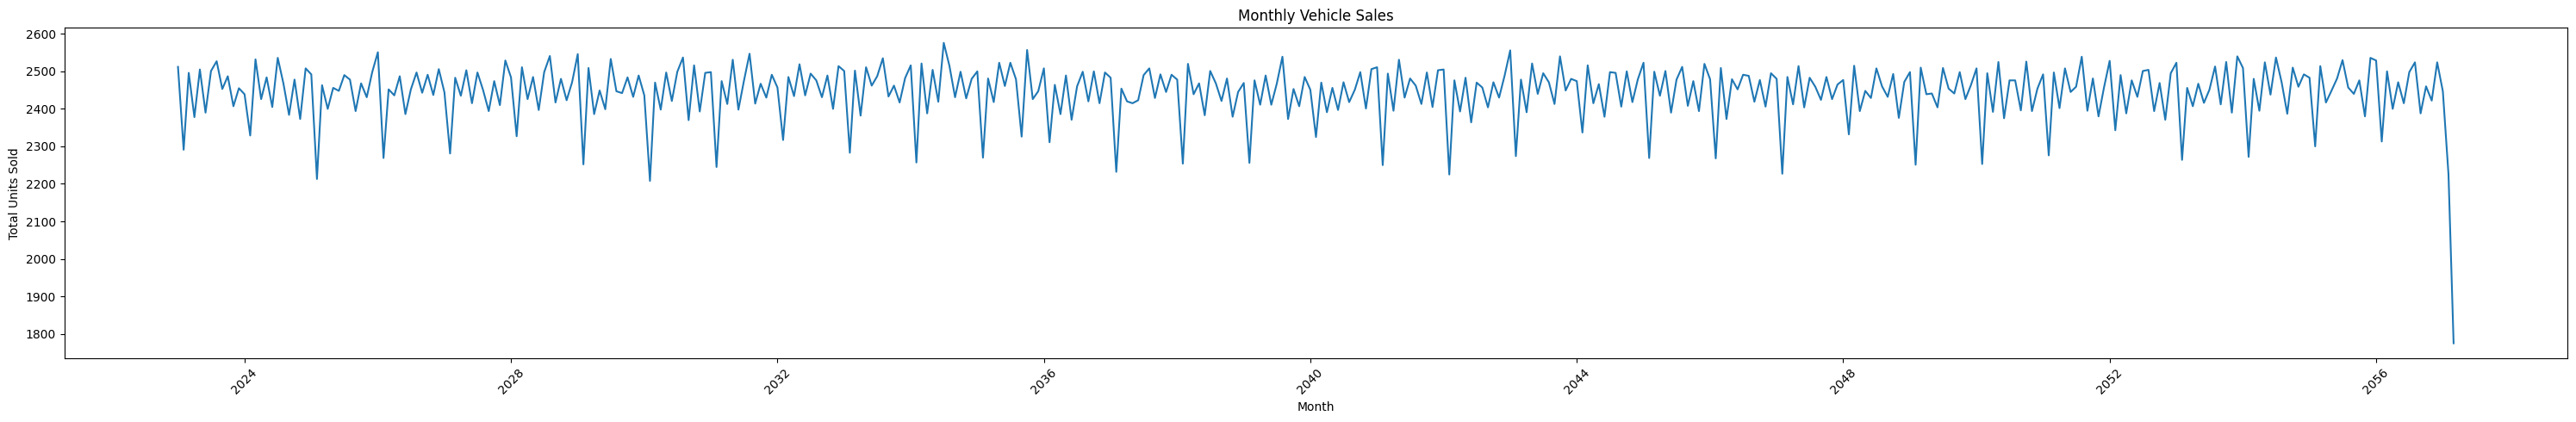

In [ ]:
plt.figure(figsize=(30, 5))
plt.plot(result2["month"], result2["total_units"])
plt.title("Monthly Vehicle Sales")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Internal Mapping for Feature 2
- **What the application does:** computes monthly sales trends  
- **What DuckDB does internally:** scans only `sale_date` and `units_sold`, then applies date bucketing and aggregation in batches  
- **Why it matters:** this makes time-series analysis efficient without scanning full rows

## 6. Application Feature 3: Incentive and Demand Relationship
This query compares incentives and total sales across regions.

In [ ]:
query3 = """
SELECT region,
       AVG(incentive) AS avg_incentive,
       SUM(units_sold) AS total_units
FROM sales
GROUP BY region
ORDER BY avg_incentive DESC
"""

result3 = con.execute(query3).fetchdf()
display(result3)

,region,avg_incentive,total_units
0,West,2501.823291,318121.0
1,South,2196.671327,256342.0
2,East,1799.283360,243358.0
3,Midwest,1497.424034,186797.0


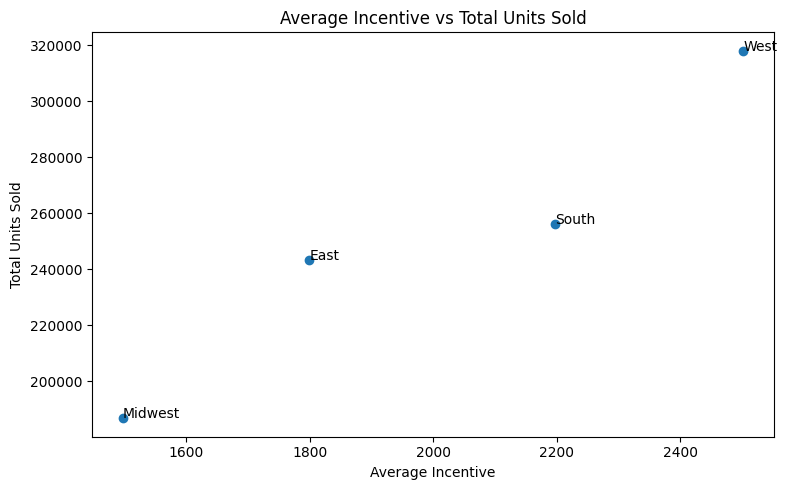

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(result3["avg_incentive"], result3["total_units"])
for i, row in result3.iterrows():
    plt.annotate(row["region"], (row["avg_incentive"], row["total_units"]))
plt.title("Average Incentive vs Total Units Sold")
plt.xlabel("Average Incentive")
plt.ylabel("Total Units Sold")
plt.tight_layout()
plt.show()

### Internal Mapping for Feature 3
- **What the application does:** compares incentive levels and sales across regions  
- **What DuckDB does internally:** scans only `region`, `incentive`, and `units_sold` and performs multiple aggregations in vectorized batches  
- **Why it matters:** DuckDB handles multi-metric analytical queries efficiently because it only reads the relevant columns

## 7. Show the Execution Plan
This helps connect the application query to DuckDB's internal execution behavior.

In [ ]:
explain_query = """
EXPLAIN SELECT region, SUM(units_sold) AS total_units
FROM sales
GROUP BY region
"""

plan_df = con.execute(explain_query).fetchdf()
display(plan_df)

,explain_key,explain_value
0,physical_plan,┌───────────────────────────┐\n│ PROJE...


### Interpreting the Plan
The execution plan supports the main idea of the project:

- DuckDB is optimized for analytical queries
- It reads only the columns needed for the query
- It performs aggregation efficiently using vectorized processing
- This is different from a row-based database, which would read entire rows

## 8. Comparison to a Row-Based System
DuckDB is especially strong for analytics because of its columnar storage design.

For a query like:

```sql
SELECT region, SUM(units_sold)
FROM sales
GROUP BY region;

DuckDB only needs to scan region and units_sold.

A row-based system like MySQL would read full rows, even if the query only uses two columns.
That is why DuckDB is better suited for analytical workloads.

## 9. Conclusion
This project shows how DuckDB's internal design directly affects application behavior.

Main takeaways:
- DuckDB uses **columnar storage**
- DuckDB uses **vectorized execution**
- These features make aggregation-heavy analytical queries much more efficient
- This is why DuckDB is a strong fit for demand analysis and other data analytics workloads